In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.database.db_connection import get_engine

engine = get_engine()
rfm = pd.read_sql("SELECT * FROM customer_rfm", engine)
rfm.head()

,customer_id,recency_days,frequency,monetary,r_score,f_score,m_score,rfm_score,segment
0,1,400,2,40868.24,2,1,2,212,Lost
1,2,394,2,12913.42,2,1,1,211,Lost
2,3,239,3,64978.04,3,2,4,324,Needs Attention
3,4,23,3,65718.68,5,2,4,524,Potential Loyalists
4,5,108,4,52889.60,4,3,3,433,Potential Loyalists


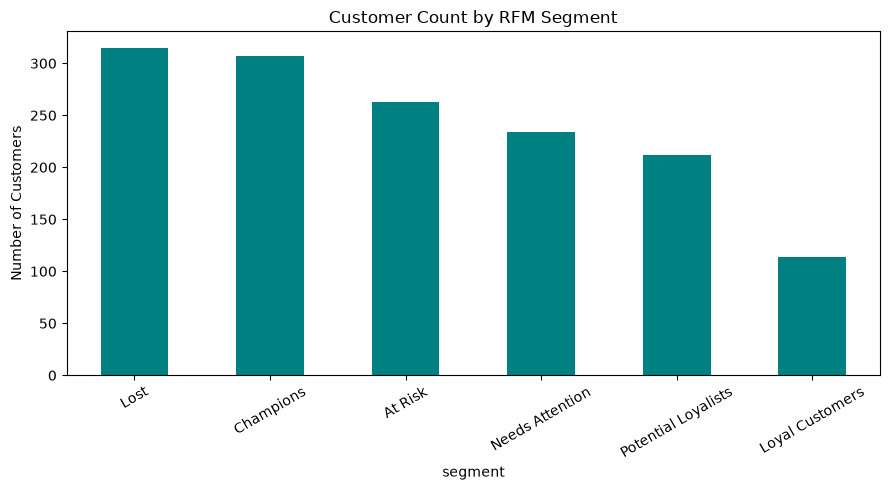

In [2]:
segment_counts = rfm["segment"].value_counts()

plt.figure(figsize=(9,5))
segment_counts.plot(kind="bar", color="teal")
plt.title("Customer Count by RFM Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

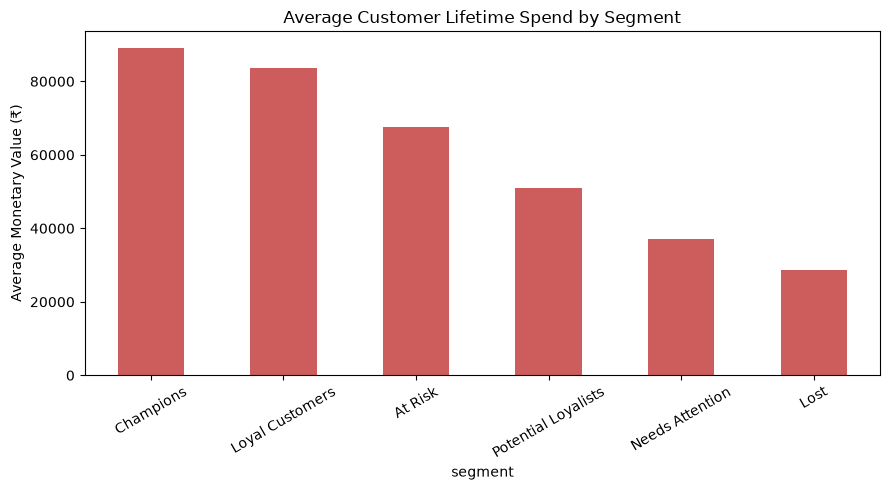

In [3]:
avg_value = rfm.groupby("segment")["monetary"].mean().sort_values(ascending=False)

plt.figure(figsize=(9,5))
avg_value.plot(kind="bar", color="indianred")
plt.title("Average Customer Lifetime Spend by Segment")
plt.ylabel("Average Monetary Value (\u20b9)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()